In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-02-19 21:13:30.707171: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Discreet Wavelet Transform version of the vortex function
def wavelet_distillation(distilled_image):
    # Perform a 2D Discrete Wavelet Transform
    # 'haar' is great for detecting intensity jumps (tumor boundaries)
    coeffs2 = pywt.dwt2(distilled_image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    
    # LL is the 'Approximation' (the general shape)
    # LH, HL, HH are 'Details' (the edges/texture)
    
    # We can stack these to create a multi-resolution feature map
    # This gives the model 4x the 'logic' to work with
    wavelet_stack = np.block([
        [LL, LH],
        [HL, HH]
    ])
    
    return wavelet_stack



# Fast Fourier Transform version of the vortex function
def myfft2(A): 
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))

In [3]:
def generate_vortex_map(f, A, m, dim=64, xmax=10, flambda=80):
    """
    Applies a vortex phase of charge 'm' to a batch of images 'A'.
    
    Parameters:
    A (ndarray): Input image batch of shape [num_images, dim, dim]
    m (int): Topological charge (1, 2, 3, etc.)
    dim (int): Pixel resolution of the grid
    xmax (float): Physical limit of the f-plane
    flambda (float): Lens parameter
    
    Returns:
    ndarray: Processed and normalized images of shape [num_images, dim, dim]
    """
    # 1. Setup Coordinates
    dx = 2 * xmax / dim
    x = np.linspace(-xmax, xmax - dx, dim)
    X, Y = np.meshgrid(x, x)
    R2 = (X**2 + Y**2)
    T = np.arctan2(Y, X)

    # 2. Create the LG Mask (Lens + Vortex Phase)
    Lens = np.exp(-1j * R2 / (flambda / 10))
    Vortex = np.exp(1j * m * T)
    LG_mask = Lens * Vortex

    # 3. Process the Batch
    num_images = A.shape[0]
    out = np.zeros_like(A, dtype=np.float64)
    
    for i in range(num_images):
        # Apply phase modulation and distillation 
        # (Assumes wavelet_distillation is defined globally)
        phase_mod = np.exp(1j * A[i] * np.pi * 2)
        distilled = f(phase_mod * LG_mask)
        
        # Calculate Magnitude
        A_mag = np.abs(distilled)
        
        # Normalize to [-1, 1] for NN compatibility
        a_min = np.amin(A_mag)
        a_diff = np.amax(A_mag) - a_min
        
        if a_diff != 0:
            out[i] = (A_mag - a_min) / a_diff * 2 - 1
        else:
            out[i] = A_mag - a_min

    return out

In [4]:
def load_data(base_path='/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/COVID-19_Radiography_Dataset/', target_dim=64, max_per_class=2000):
    # Categories define our 'y' labels: COVID=0, Normal=1, etc.
    categories = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']
    X = []
    y = []
    
    print(f"Loading images from: {base_path}")

    for idx, category in enumerate(categories):
        folder_path = os.path.join(base_path, category, 'images')
        
        if not os.path.exists(folder_path):
            continue
            
        images = os.listdir(folder_path)[:max_per_class]
        
        for img_name in tqdm(images, desc=f"Processing {category}"):
            img_path = os.path.join(folder_path, img_name)
            
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            
            # Resize and Normalize
            img_res = cv2.resize(img, (target_dim, target_dim))
            img_final = img_res.astype('float32') / 255.0
            
            X.append(img_final)
            y.append(idx) # Store the numerical label

    # Convert to numpy arrays for TensorFlow/Keras
    return np.array(X), np.array(y)

In [5]:
from sklearn.model_selection import train_test_split

# Assuming X_gt and y_labels are your processed numpy arrays
# X_gt shape: (N, 64, 64)
# y_labels shape: (N,)

X, Y = load_data()

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    Y, 
    test_size=0.20,      # 20% for testing
    random_state=42,     # Fixed seed for reproducibility (essential for PhD)
    stratify=Y    # Ensures train/test have same % of COVID vs Normal
)

print(f"Training set size: {x_train.shape[0]}")
print(f"Testing set size: {x_test.shape[0]}")

Loading images from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/COVID-19_Radiography_Dataset/


Processing Viral Pneumonia: 100%|██████████| 1345/1345 [00:25<00:00, 53.39it/s]


Training set size: 5876
Testing set size: 1469


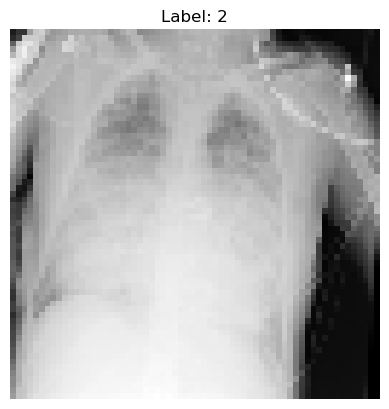

In [6]:
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.title(f"Label: {y_train[0]}")
plt.show()

I0000 00:00:1771564548.246958    7206 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


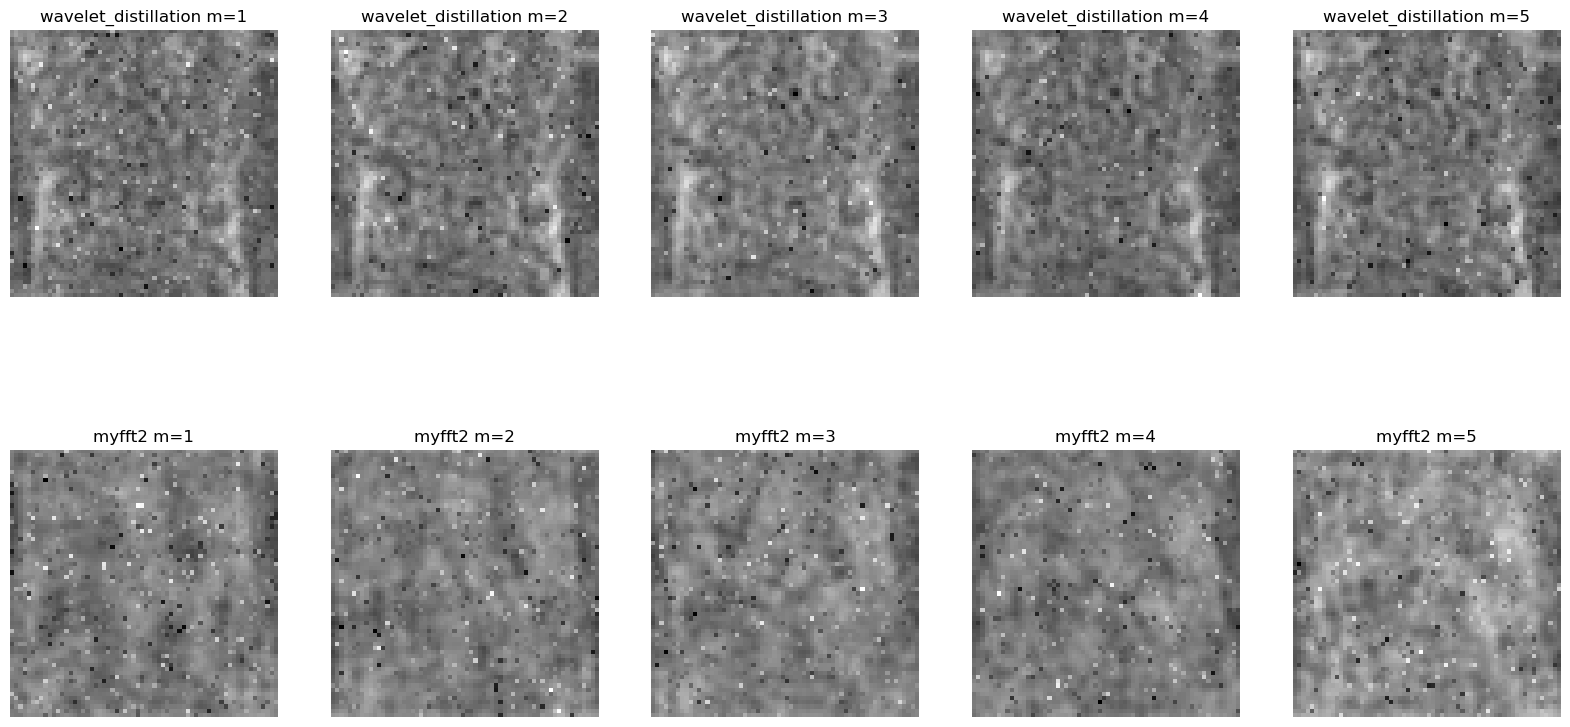

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
img = []

for transform in [wavelet_distillation, myfft2]:
    for i in range(1, 6, 1):
        # --- ROBUST CUSTOM OBJECTS DICTIONARY ---
        # We map all possible conflicting strings (keys) to their current TensorFlow objects (values).
        CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


        # ---Loading Loop (Adjust the path as needed) ---

        # IMPORTANT: I'm using the fixed path structure from our previous conversation.
        model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/{transform.__name__}_m_{i}.keras'

        reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)


        # Load the same data you trained on (or new data) and run predictions
        X = generate_vortex_map(transform, np.array([x_train[2]]), m=i)

        recon_tumor = reconstruction_model.predict(X.reshape(1, -1)).reshape(64, 64)
        img.append(recon_tumor)

        # Display the original and reconstructed images side by side
        ax = axes[(i-1) + (0 if transform == wavelet_distillation else 5)]
        ax.imshow(recon_tumor, cmap='gray')
        ax.set_title(f'{transform.__name__} m={i}')
        ax.axis('off')
    
plt.show()

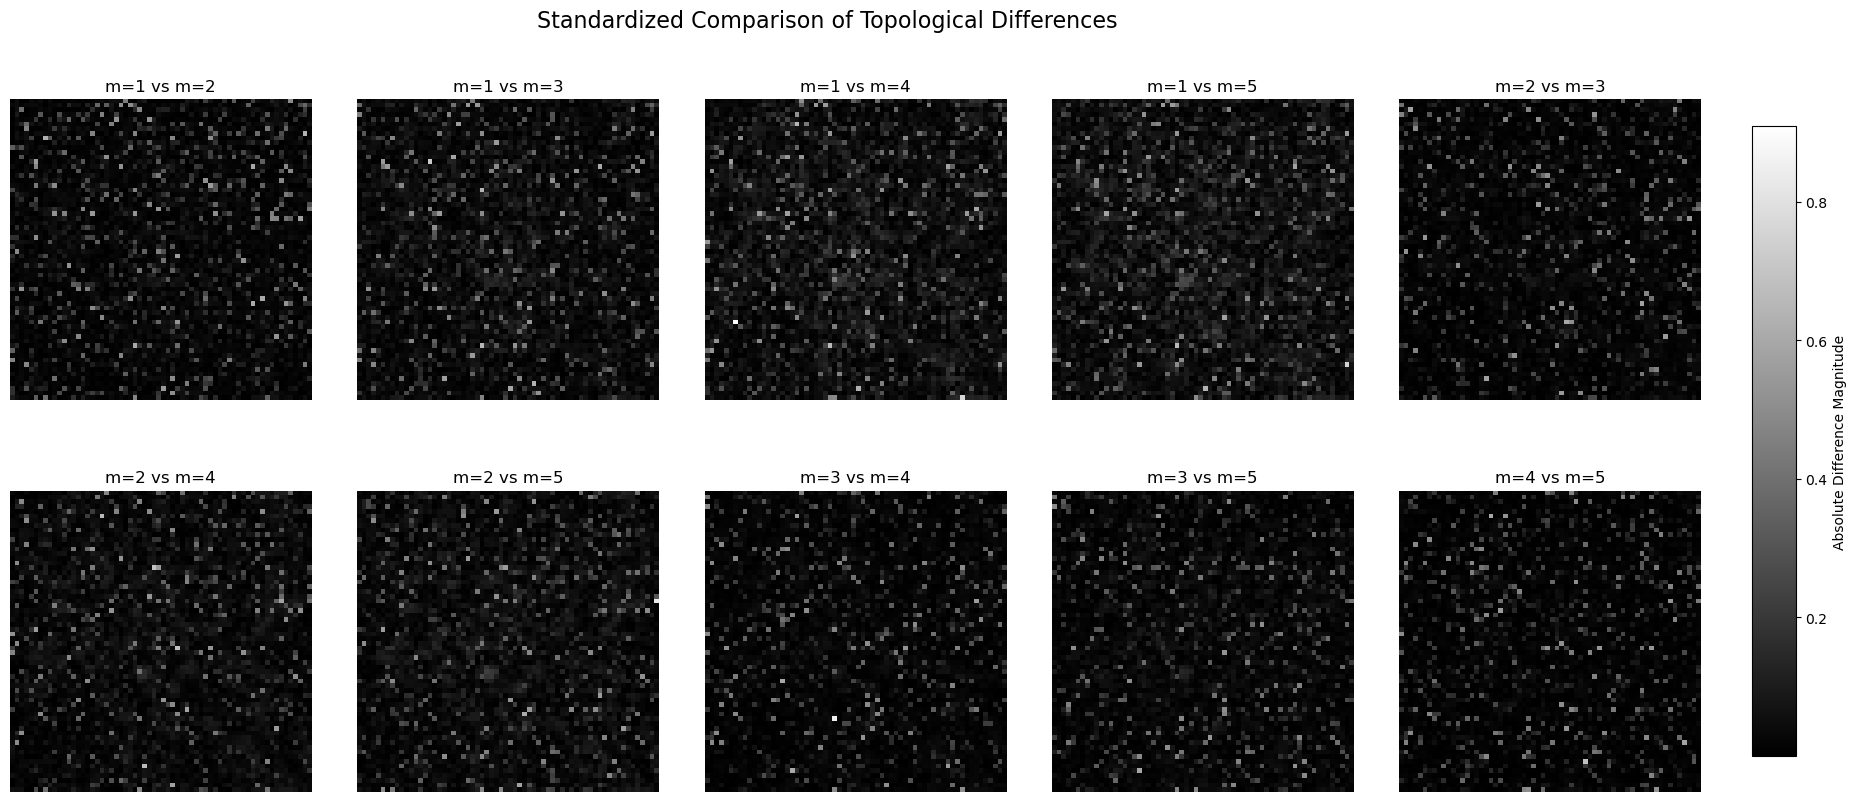

In [8]:
from itertools import combinations

# Assuming img is your array of shape (5, 64, 64)
# img[0] -> m=1, img[1] -> m=2, ..., img[4] -> m=5

def plot_shared_colorbar_differences(img_array):
    # 1. Generate combinations
    indices = list(combinations(range(5), 2))
    
    # 2. Calculate all differences first to find the global max
    # This ensures the colorbar represents the absolute scale of the data
    diffs = [np.abs(img_array[i] - img_array[j]) for i, j in indices]
    global_max = np.max(diffs)
    global_min = np.min(diffs)

    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()
    
    for i, (idx1, idx2) in enumerate(indices):
        # Plot with fixed vmin and vmax
        im = axes[i].imshow(diffs[i], cmap='gray', vmin=global_min, vmax=global_max)
        axes[i].set_title(f"m={idx1+1} vs m={idx2+1}", fontsize=12)
        axes[i].axis('off')

    # 3. Add one standard colorbar for the whole figure
    # 'shrink' and 'aspect' help the bar fit nicely next to the grid
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, label='Absolute Difference Magnitude')

    plt.subplots_adjust(right=0.9, hspace=0.3, wspace=0.1)
    fig.suptitle("Standardized Comparison of Topological Differences", fontsize=16, y=0.98)
    plt.show()

# Run the function
plot_shared_colorbar_differences(img)

In [22]:
def process_entire_dataset(X_gt, f_distillation, m_range=[1, 2, 3, 4, 5]):
    """
    1. Generates vortex maps for the entire dataset.
    2. Passes them through the reconstruction model.
    3. Stores the reconstructed images for further Intra/Inter class analysis.
    """
    num_samples = X_gt.shape[0]
    # results shape: (5, num_samples, 64, 64)
    results = np.zeros((len(m_range), num_samples, 64, 64), dtype='float32')
    
    for idx, m_val in enumerate(m_range):
        print(f"\n--- Processing m = {m_val} ---")
        
        # 1. Generate the vortex maps for the whole batch
        # Output shape: (num_samples, 64, 64)
        X_vortex = generate_vortex_map(f_distillation, X_gt, m=m_val)
        
        # 2. Reshape for the Linear Model (N, 4096)
        X_flat = X_vortex.reshape(num_samples, 4096)
        
        # IMPORTANT: I'm using the fixed path structure from our previous conversation.
        model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/2pi/{f_distillation.__name__}_m_{m_val}.keras'

        reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)
        
        # 3. Predict the entire batch at once
        # Output shape: (num_samples, 4096)
        predictions_flat = reconstruction_model.predict(X_flat)
        
        # 4. Reshape back to (num_samples, 64, 64) and store
        results[idx] = predictions_flat.reshape(num_samples, 64, 64).astype('float32')
        
    return results

# Usage
all_reconstructions = process_entire_dataset(x_train, wavelet_distillation)


--- Processing m = 1 ---
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 2 ---
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 3 ---
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 4 ---
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Processing m = 5 ---
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
def analyze_class_separability(X_vortex, y_labels, num_pairs=100):
    # Indices for each class
    idx_covid = np.where(y_labels == 0)[0]
    idx_normal = np.where(y_labels == 1)[0]
    
    intra_diffs = []
    inter_diffs = []

    for _ in range(num_pairs):
        # Intra-class: COVID Patient A vs COVID Patient B
        i1, i2 = np.random.choice(idx_covid, 2, replace=False)
        intra_diffs.append(np.abs(X_vortex[i1] - X_vortex[i2]))
        
        # Inter-class: COVID Patient A vs Normal Patient B
        j1 = np.random.choice(idx_covid)
        j2 = np.random.choice(idx_normal)
        inter_diffs.append(np.abs(X_vortex[j1] - X_vortex[j2]))

    # Calculate Mean Difference Maps
    mean_intra = np.mean(intra_diffs, axis=0)
    mean_inter = np.mean(inter_diffs, axis=0)
    
    return mean_intra, mean_inter


m5_intra, m5_inter = analyze_class_separability(all_reconstructions[4], y_test)
m1_intra, m1_inter = analyze_class_separability(all_reconstructions[0], y_test)
m2_intra, m2_inter = analyze_class_separability(all_reconstructions[1], y_test)
m3_intra, m3_inter = analyze_class_separability(all_reconstructions[2], y_test)
m4_intra, m4_inter = analyze_class_separability(all_reconstructions[3], y_test)

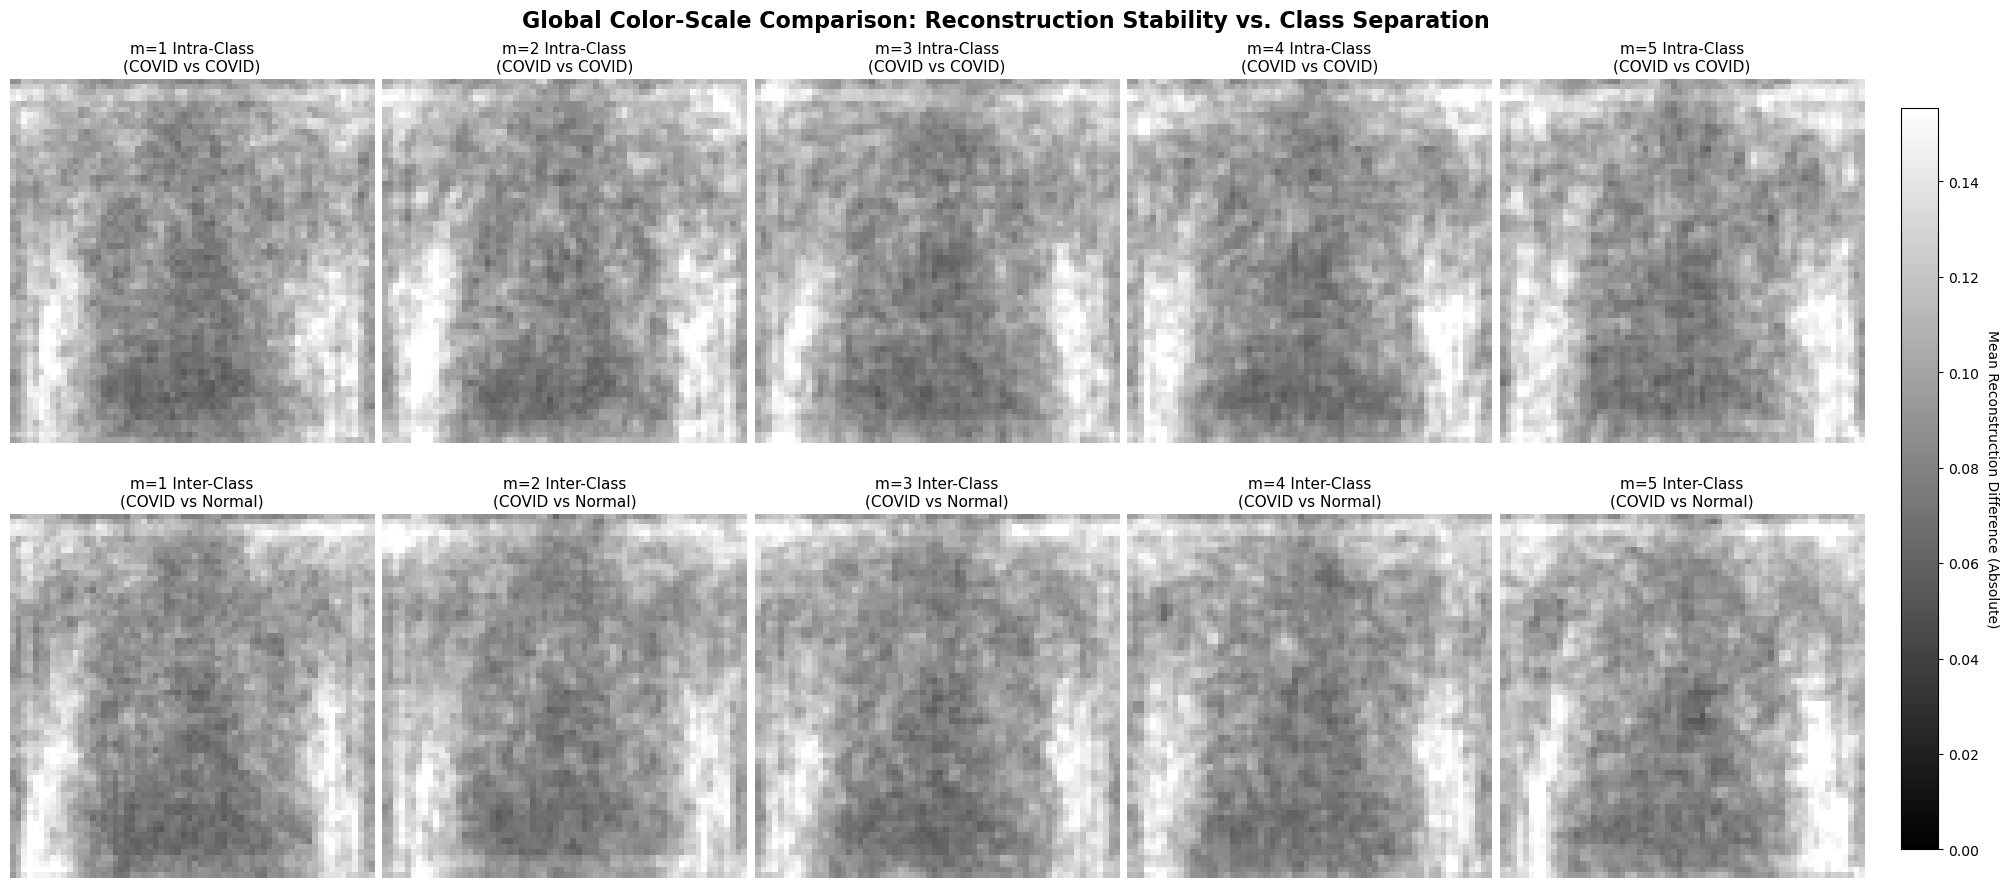

In [38]:
# 1. Organize your data
intra_list = [m1_intra, m2_intra, m3_intra, m4_intra, m5_intra]
inter_list = [m1_inter, m2_inter, m3_inter, m4_inter, m5_inter]
m_vals = [1, 2, 3, 4, 5]

# 2. Calculate Global Vmax (ignoring the top 2% of outliers for better contrast)
all_data = np.array(intra_list + inter_list)
global_vmax = np.percentile(all_data, 98)
global_vmin = 0  # Absolute difference is always positive

# 3. Create the Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 9), constrained_layout=True)

for i in range(5):
    # --- Top Row: Intra-Class (Anatomical Variance) ---
    im_intra = axes[0, i].imshow(intra_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[0, i].set_title(f"m={m_vals[i]} Intra-Class\n(COVID vs COVID)", fontsize=11)
    axes[0, i].axis('off')
    
    # --- Bottom Row: Inter-Class (Disease Signature) ---
    im_inter = axes[1, i].imshow(inter_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[1, i].set_title(f"m={m_vals[i]} Inter-Class\n(COVID vs Normal)", fontsize=11)
    axes[1, i].axis('off')

# 4. Add a shared Colorbar
cbar = fig.colorbar(im_inter, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Reconstruction Difference (Absolute)', rotation=270, labelpad=15)

plt.suptitle("Global Color-Scale Comparison: Reconstruction Stability vs. Class Separation", 
             fontsize=16, fontweight='bold')

plt.show()

In [39]:
correlation = np.corrcoef(m5_inter.flatten(), m5_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m4_inter.flatten(), m4_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m3_inter.flatten(), m3_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m2_inter.flatten(), m2_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

correlation = np.corrcoef(m1_inter.flatten(), m1_intra.flatten())[0, 1]
print(f"Correlation between Inter and Intra: {correlation:.6f}")

Correlation between Inter and Intra: 0.848957
Correlation between Inter and Intra: 0.857599
Correlation between Inter and Intra: 0.875904
Correlation between Inter and Intra: 0.846384
Correlation between Inter and Intra: 0.853279


In [ ]:
m5_intra, m5_inter = analyze_class_separability(all_reconstructions[4], y_train, 3)
m1_intra, m1_inter = analyze_class_separability(all_reconstructions[0], y_train, 3)
m2_intra, m2_inter = analyze_class_separability(all_reconstructions[1], y_train, 3)
m3_intra, m3_inter = analyze_class_separability(all_reconstructions[2], y_train, 3)
m4_intra, m4_inter = analyze_class_separability(all_reconstructions[3], y_train, 3)


# 1. Organize your data
intra_list = [m1_intra, m2_intra, m3_intra, m4_intra, m5_intra]
inter_list = [m1_inter, m2_inter, m3_inter, m4_inter, m5_inter]
m_vals = [1, 2, 3, 4, 5]

# 2. Calculate Global Vmax (ignoring the top 2% of outliers for better contrast)
all_data = np.array(intra_list + inter_list)
global_vmax = np.percentile(all_data, 98)
global_vmin = 0  # Absolute difference is always positive

# 3. Create the Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 9), constrained_layout=True)

for i in range(5):
    # --- Top Row: Intra-Class (Anatomical Variance) ---
    im_intra = axes[0, i].imshow(intra_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[0, i].set_title(f"m={m_vals[i]} Intra-Class\n(VP vs VP)", fontsize=11)
    axes[0, i].axis('off')
    
    # --- Bottom Row: Inter-Class (Disease Signature) ---
    im_inter = axes[1, i].imshow(inter_list[i], cmap='gray', 
                                 vmin=global_vmin, vmax=global_vmax)
    axes[1, i].set_title(f"m={m_vals[i]} Inter-Class\n(VP vs Normal)", fontsize=11)
    axes[1, i].axis('off')

# 4. Add a shared Colorbar
cbar = fig.colorbar(im_inter, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Mean Reconstruction Difference (Absolute)', rotation=270, labelpad=15)

plt.suptitle("Global Color-Scale Comparison: Reconstruction Stability vs. Class Separation", 
             fontsize=16, fontweight='bold')

plt.show()

ValueError: 'a' cannot be empty unless no samples are taken